# MAG7 bullish/bearish/neutral LTN pipeline inspection

This notebook is a detailed audit of the full pipeline you ran:

1. raw MAG7 market-news headlines
2. first-pass strict event extraction
3. deduplication into event episodes
4. price/market data and abnormal-return calculation
5. bullish/bearish/neutral realised labels
6. second-pass LLM event refinement
7. LTN-style soft rule mining
8. validation and held-out test evaluation
9. horizon effects and data-quality checks

It is designed to be inspection-first. It does **not** rerun the expensive GPU classification. It reads the saved outputs from:

- `outputs/1_mag7_strict_event_full`
- `outputs/2_bull_bear_mining`

The purpose is to understand every stage and spot where the research design is strong or weak.


## Current headline findings from the saved run

From the saved output files:

- 63,459 MAG7-requested headlines were processed.
- 9,689 headlines were kept by the first strict-event LLM pass.
- 8,263 deduplicated event episodes were formed.
- 2,274 event-return rows were produced across horizons `[1, 2, 3, 5, 7, 10]`.
- At the 3-day primary horizon there are 380/381 usable labelled event rows depending on the file used.
- The bullish/bearish/neutral rule-mining run used:
  - discovery: `2023-01-01` to `2024-12-31`
  - validation: `2025-01-01` to `2025-12-31`
  - test: `2026-01-01` to `2026-06-01`
  - realised label threshold: `+/- 0.5%` abnormal return at the primary 3-day horizon.

Main result so far:

- LLM-only `expected_label` test accuracy: about **38.1%**
- LTN/rule-matched test accuracy: about **60.0%**
- But the rules only matched **20 of 63** held-out test events.

Interpretation:

> The LTN/rule layer is not yet a complete market-state classifier, but it does improve consistency when it chooses to fire. The current signal is selective and weakened by small test sample size, low neutral representation, and some article/ticker contamination.


In [2]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
STRICT_DIR = OUTPUT_ROOT / "1_mag7_strict_event_full"
BULL_DIR = OUTPUT_ROOT / "2_bull_bear_mining"

# Fallbacks for the original container output names.
if not STRICT_DIR.exists():
    STRICT_DIR = OUTPUT_ROOT / "mag7_strict_event_full"
if not BULL_DIR.exists():
    BULL_DIR = OUTPUT_ROOT / "mag7_bull_bear_rule_mining"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STRICT_DIR:", STRICT_DIR, STRICT_DIR.exists())
print("BULL_DIR:", BULL_DIR, BULL_DIR.exists())


PROJECT_ROOT: c:\Users\kiera\OneDrive\University\Univeristy\Studying\Masters\Dissertation\Sentiment project
STRICT_DIR: c:\Users\kiera\OneDrive\University\Univeristy\Studying\Masters\Dissertation\Sentiment project\outputs\1_mag7_strict_event_full True
BULL_DIR: c:\Users\kiera\OneDrive\University\Univeristy\Studying\Masters\Dissertation\Sentiment project\outputs\2_bull_bear_mining True


## 1. What files are being inspected?

The strict-event folder is the output of the first overnight run. It contains the headline-level LLM classifications, deduplicated event episodes, abnormal returns, and event-type/horizon summaries.

The bull/bear folder is the output of the second run. It contains the second-pass event refinement, realised bullish/bearish/neutral labels, mined LTN rules, and validation/test summaries.


In [3]:
def list_files(folder: Path) -> pd.DataFrame:
    rows = []
    for f in sorted(folder.glob("*")):
        if f.is_file():
            rows.append({"name": f.name, "size_kb": round(f.stat().st_size / 1024, 1), "modified": pd.Timestamp(f.stat().st_mtime, unit="s")})
    return pd.DataFrame(rows)

display(list_files(STRICT_DIR))
display(list_files(BULL_DIR))


,name,size_kb,modified
0,classification_checkpoint.parquet,6876.2,2026-06-25 07:56:38.378106356
1,event_audit_sample.csv,49.4,2026-06-25 07:56:37.264193057
2,event_episodes.parquet,865.0,2026-06-25 07:56:37.871677637
3,event_returns.parquet,84.0,2026-06-25 07:56:37.566159487
4,event_type_horizon_summary.csv,16.9,2026-06-25 07:56:37.095044613
5,run.log,164.4,2026-06-25 07:56:37.778629780
6,run_manifest.json,0.2,2026-06-25 07:56:36.948672533


,name,size_kb,modified
0,candidate_rules_discovery.csv,11.2,2026-06-25 15:58:29.176343441
1,candidate_rules_validation.csv,8.2,2026-06-25 15:58:29.295792103
2,event_refinement_checkpoint.parquet,116.2,2026-06-25 15:58:30.723942995
3,primary_horizon_event_audit.csv,119.9,2026-06-25 15:58:30.850156546
4,refined_event_returns.parquet,126.2,2026-06-25 15:58:31.469054222
5,rule_system_discovery_summary.csv,1.2,2026-06-25 15:58:31.016968489
6,rule_system_test_summary.csv,1.1,2026-06-25 15:58:31.348206997
7,rule_system_validation_summary.csv,1.2,2026-06-25 15:58:32.206273794
8,run.log,8.7,2026-06-25 15:58:31.645567894
9,run_manifest.json,0.6,2026-06-25 15:58:32.023003101


In [4]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

strict_manifest = read_json(STRICT_DIR / "run_manifest.json")
bull_manifest = read_json(BULL_DIR / "run_manifest.json")

print("Strict-event manifest")
display(strict_manifest)

print("Bull/bear LTN manifest")
display(bull_manifest)


Strict-event manifest


{'start': '2023-01',
 'end': '2026-05',
 'articles': 63459,
 'kept': 9689,
 'events': 8263,
 'event_return_rows': 2274,
 'horizons': [1, 2, 3, 5, 7, 10]}

Bull/bear LTN manifest


{'input_dir': 'outputs/mag7_strict_event_full',
 'out_dir': 'outputs/mag7_bull_bear_rule_mining',
 'model_id': 'Qwen/Qwen2.5-7B-Instruct',
 'labels': ['bearish', 'bullish', 'neutral'],
 'primary_horizon': 3,
 'return_threshold': 0.005,
 'discovery': ['2023-01-01', '2024-12-31'],
 'validation': ['2025-01-01', '2025-12-31'],
 'test': ['2026-01-01', '2026-06-01'],
 'ltn_version': 'unknown',
 'ltn_epochs': 800,
 'ltn_lr': 0.05,
 'ltn_min_weight': 0.6,
 'n_events': 381,
 'n_refined': 381,
 'n_candidate_rules': 41,
 'n_selected_rules': 10}

## 2. Load all saved pipeline outputs

This section loads every saved output table. If a table fails to load, it usually means the local Python environment is missing `pyarrow`.


In [5]:
classified = pd.read_parquet(STRICT_DIR / "classification_checkpoint.parquet")
episodes = pd.read_parquet(STRICT_DIR / "event_episodes.parquet")
event_returns = pd.read_parquet(STRICT_DIR / "event_returns.parquet")
event_summary = pd.read_csv(STRICT_DIR / "event_type_horizon_summary.csv")

refinements = pd.read_parquet(BULL_DIR / "event_refinement_checkpoint.parquet")
refined_returns = pd.read_parquet(BULL_DIR / "refined_event_returns.parquet")
primary_audit = pd.read_csv(BULL_DIR / "primary_horizon_event_audit.csv")
rules_discovery = pd.read_csv(BULL_DIR / "candidate_rules_discovery.csv")
rules_validation = pd.read_csv(BULL_DIR / "candidate_rules_validation.csv")
summary_discovery = pd.read_csv(BULL_DIR / "rule_system_discovery_summary.csv")
summary_validation = pd.read_csv(BULL_DIR / "rule_system_validation_summary.csv")
summary_test = pd.read_csv(BULL_DIR / "rule_system_test_summary.csv")

tables = {
    "classified": classified,
    "episodes": episodes,
    "event_returns": event_returns,
    "event_summary": event_summary,
    "refinements": refinements,
    "refined_returns": refined_returns,
    "primary_audit": primary_audit,
    "rules_discovery": rules_discovery,
    "rules_validation": rules_validation,
    "summary_discovery": summary_discovery,
    "summary_validation": summary_validation,
    "summary_test": summary_test,
}

pd.DataFrame([
    {"table": name, "rows": len(df), "columns": len(df.columns), "column_names": ", ".join(df.columns)}
    for name, df in tables.items()
])


,table,rows,columns,column_names
0,classified,63459,11,"article_uid, time_published, title, ticker, keep, event_type, direction, event_key, mechanism, confidence, raw_response"
1,episodes,8263,8,"ticker, time_published, event_type, direction, event_key, mechanism, representative_title, article_count"
2,event_returns,2274,12,"ticker, time_published, event_type, direction, event_key, mechanism, representative_title, article_count, event_date, horizon_days, abnormal_return, direction_agrees"
3,event_summary,150,9,"ticker, event_type, horizon_days, n_events, mean_abnormal_return_pct, mean_abnormal_signflip_p, mean_absolute_abnormal_return_pct, direction_agreement_pct, direction_binomial_p"
4,refinements,381,18,"event_id, ticker, time_published, event_date, event_type, direction, event_key, mechanism, representative_title, article_count, include_candidate, expected_label, event_subtype..."
5,refined_returns,2274,21,"ticker, time_published, event_type, direction, event_key, mechanism, representative_title, article_count, event_date, horizon_days, abnormal_return, direction_agrees, event_id,..."
6,primary_audit,380,15,"ticker, event_date, time_published, representative_title, event_type, direction, event_subtype, valuation_channel, materiality_strength, novelty, include_candidate, expected_la..."
7,rules_discovery,41,16,"condition, rule_label, ltn_rule_truth, empirical_rule_accuracy, rule_score, ltn_final_loss, discovery_n, discovery_accuracy_pct, discovery_mean_ar_pct, discovery_mean_abs_ar_pc..."
8,rules_validation,39,12,"condition, rule_label, validation_n, validation_accuracy_pct, validation_mean_ar_pct, validation_mean_abs_ar_pct, validation_bullish_rate_pct, validation_bearish_rate_pct, vali..."
9,summary_discovery,7,11,"group, discovery_n, discovery_accuracy_pct, discovery_mean_ar_pct, discovery_mean_abs_ar_pct, discovery_bullish_rate_pct, discovery_bearish_rate_pct, discovery_neutral_rate_pct..."


## 3. What news data is being fed in?

The first run read monthly market-news parquet files from Hugging Face:

- news repo: `cookekieran/alphavantage-market-news`
- months: `2023-01` to `2026-05`
- tickers: `AAPL`, `AMZN`, `GOOGL`, `META`, `MSFT`, `NVDA`, `TSLA`

The strict-event classifier was not given full article bodies. It used the headline-level fields:

- `article_uid`
- `time_published`
- `title`
- `ticker` / `requested_entity`

This means the first LLM pass is a headline-level event extractor, not a full-article reader.


In [6]:
print("Headline-level fields used by first-pass classification:")
display(classified[["article_uid", "time_published", "ticker", "title"]].head(10))

print("Date range by ticker")
display(
    classified.assign(time_published=pd.to_datetime(classified["time_published"], utc=True))
    .groupby("ticker")["time_published"]
    .agg(["min", "max", "count"])
)


Headline-level fields used by first-pass classification:


,article_uid,time_published,ticker,title
0,cc943125f2c299c334e9484c073748f4,2023-01-02 04:52:00+00:00,AAPL,What is TSMC?
1,e94cd66eaeab77a193199183b1a77cbc,2023-01-03 04:06:10+00:00,AAPL,"If You Invested $100 in Berkshire Hathaway in 1965, This Is How Much You Would Have Today"
2,aa9775754e1566cebaeea81ca19ecca4,2023-01-03 04:06:10+00:00,AAPL,"If You Invested $100 in Berkshire Hathaway in 1965, This Is How Much You Would Have Today"
3,eec1c245936a45f5e7e4f9134ac6e54d,2023-01-03 12:05:00+00:00,AAPL,Tuesday's ETF with Unusual Volume: IWL
4,f1a28840cb9391fc012bce188488f0e4,2023-01-04 09:26:00+00:00,AAPL,Salesforce to lay off 10% of workforce to cut costs amid economic downturn
5,6217c394b1954da3f19674ff41f5fbe9,2023-01-04 11:52:00+00:00,AAPL,Apple to sign Luxshare for iPhone production in China - FT
6,21f04789fa15efceab5ae127c932b985,2023-01-05 03:59:02+00:00,AAPL,Apple brings AI narration to audiobooks
7,81aa1489ed05c97cebd528aca2b0d057,2023-01-05 15:29:00+00:00,AAPL,"Android has a response to iPhone’s satellite connection, thanks to Qualcomm"
8,a525cf05a0a5b0536550ca77425ae4ae,2023-01-06 04:25:43+00:00,AAPL,Nordstrom appoints Atticus Tysen to its board of directors
9,60d54f8ae87e43840597ca0f7dd2f711,2023-01-06 04:25:59+00:00,AAPL,Qualcomm partners with Iridium to develop satellite connectivity


Date range by ticker


,min,max,count
ticker,,,
AAPL,2023-01-02 04:52:00+00:00,2026-05-31 23:10:42+00:00,6855
AMZN,2023-01-03 23:51:43+00:00,2026-05-31 22:07:15+00:00,8631
GOOGL,2023-01-03 04:55:16+00:00,2026-05-31 17:31:05+00:00,6084
META,2023-01-03 00:00:00+00:00,2026-05-31 12:07:30+00:00,2119
MSFT,2023-01-03 03:59:02+00:00,2026-05-31 21:07:44+00:00,13735
NVDA,2023-01-03 04:36:46+00:00,2026-05-31 23:39:24+00:00,20475
TSLA,2023-01-02 04:51:49+00:00,2026-05-31 23:50:00+00:00,5560


In [8]:
print("First-pass strict-event kept/rejected counts")
display(classified["keep"].value_counts(dropna=False).rename_axis("keep").reset_index(name="n"))

print("Kept rate by ticker")
display(
    classified.groupby("ticker")["keep"]
    .agg(total="size", kept="sum", kept_rate=lambda s: s.mean())
    .assign(kept_rate_pct=lambda d: 100*d["kept_rate"])
    .sort_values("kept_rate_pct", ascending=False)
)

print("Kept events by broad event_type")
display(
    classified.loc[classified["keep"]]
    .groupby(["event_type", "direction"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)


First-pass strict-event kept/rejected counts


,keep,n
0,False,53770
1,True,9689


Kept rate by ticker


,total,kept,kept_rate,kept_rate_pct
ticker,,,,
META,2119,545,0.257197,25.719679
NVDA,20475,3918,0.191355,19.135531
TSLA,5560,853,0.153417,15.341727
AMZN,8631,1259,0.145870,14.586954
GOOGL,6084,735,0.120809,12.080868
AAPL,6855,828,0.120788,12.078775
MSFT,13735,1551,0.112923,11.292319


Kept events by broad event_type


,event_type,direction,n
14,strategy_capital_allocation,positive,2709
10,regulatory_legal_outcome,negative,2241
8,novel_product_event,positive,1337
5,earnings_guidance,positive,977
2,demand_supply_revision,positive,675
11,regulatory_legal_outcome,positive,660
13,strategy_capital_allocation,negative,346
1,demand_supply_revision,negative,274
4,earnings_guidance,negative,194
12,strategy_capital_allocation,mixed,82


## 4. What classifies as an event?

The first-pass event classifier keeps a headline only when it looks like a **new, confirmed, company-specific event** with a plausible cash-flow, valuation, or risk mechanism.

Allowed broad event types:

- `earnings_guidance`
- `demand_supply_revision`
- `regulatory_legal_outcome`
- `strategy_capital_allocation`
- `novel_product_event`

The first-pass classifier rejects things like:

- ETF/index/list mentions
- analyst opinion
- rumours/previews
- generic commentary
- routine product updates
- repeated coverage
- legal process updates without clear materiality

The saved classification output gives the LLM's raw JSON response, which makes the event extraction auditable.


In [9]:
print("Examples kept as strict events")
display(
    classified.loc[classified["keep"], ["ticker", "time_published", "title", "event_type", "direction", "event_key", "mechanism", "confidence"]]
    .sample(min(15, int(classified["keep"].sum())), random_state=7)
)

print("Examples rejected")
display(
    classified.loc[~classified["keep"], ["ticker", "time_published", "title", "event_type", "direction", "event_key", "mechanism", "confidence"]]
    .sample(15, random_state=7)
)


Examples kept as strict events


,ticker,time_published,title,event_type,direction,event_key,mechanism,confidence
25482,MSFT,2025-01-08 06:24:50+00:00,Dell picks AMD for business PCs,strategy_capital_allocation,positive,dell_amd_business_pcs,supply_chain_reconfiguration,high
45573,NVDA,2025-11-04 08:19:00+00:00,"Uber’s upbeat earnings fail to lift the stock, as a costly push for self-driving cars ramps up",regulatory_legal_outcome,negative,costly_self_driving_cars_initiative,increased_operating_expenses,high
59411,TSLA,2025-10-14 15:15:42+00:00,Tesla (TSLA) Stock; Drops 2.55% as Cybertruck Sales Plunge 63% in Q3,demand_supply_revision,negative,Cybertruck_Sales_Plunge,reduction_in_demand,high
31960,MSFT,2026-02-06 10:27:40+00:00,"AG Files Motion To Reopen ""Conditional Approval"" Of DTE Data Center Contracts",regulatory_legal_outcome,negative,AG_Motion_To_Reopen_Conditional_Approval,legal motion to reopen conditional approval,high
9663,AMZN,2025-11-04 10:23:00+00:00,Newly issued stock from Amazon- and GE-backed electric-plane maker rises in its first day of trading,novel_product_event,positive,electric_plane_making_company_ipo,initial_public_offering_of_newly_issued_stock,high
59654,TSLA,2025-10-16 01:13:15+00:00,Tesla Courtroom Drama: Musk's Mega-Pay Package Gets the Boot by Delaware Court! - OpenTools,regulatory_legal_outcome,negative,court_ruling_on_executive_compensation,Delaware Court decision to invalidate Musk's executive compensation package,high
12036,AMZN,2026-02-05 17:29:01+00:00,Earnings call transcript: First Industrial Realty Trust Q4 2025 earnings beat,earnings_guidance,positive,Q4_2025_earnings_beat,revenue_and_profit_exceedance,high
28143,MSFT,2025-10-15 17:06:16+00:00,Microsoft to avoid French antitrust investigation as rival says its complaint will be dismissed - MarketScreener,regulatory_legal_outcome,positive,MSFT_french_antitrust_investigation_avoidance,dismissal_of_complaint,high
24472,MSFT,2023-12-22 19:13:08+00:00,"Microsoft closes on 1,030 acres of land in Mount Pleasant; company is now largest land owner in TID 5",strategy_capital_allocation,positive,land_acquisition_microsoft,real estate investment for potential data center expansion,high
7017,AMZN,2023-03-14 23:57:00+00:00,Amazon Fails to Dismiss California Suit Over Inflated Prices,regulatory_legal_outcome,negative,california_suit_inflated_prices,legal_action,confirmed


Examples rejected


,ticker,time_published,title,event_type,direction,event_key,mechanism,confidence
24134,MSFT,2023-07-03 23:16:11+00:00,SaaS Paid Marketing Channels: Which Are Worth the Investment?,none,mixed,,,
23332,META,2026-05-01 09:38:58+00:00,"Northern Financial Advisors Inc Sells 6,179 Shares of JPMorgan Chase & Co. $JPM",none,mixed,,,
18952,GOOGL,2026-01-29 14:33:35+00:00,Should You Forget BigBear.ai and Buy These 2 Artificial Intelligence (AI) Stocks Instead?,none,mixed,,,
21741,META,2024-10-21 00:00:00+00:00,Sui Launches ‘Incubator’ Hub in Dubai for ‘On the Spot’ Solution Engineering,none,mixed,,,
1596,AAPL,2025-10-15 05:00:00+00:00,"Apple to build upcoming HomePod with screen, tabletop robot in Vietnam - The Star",none,mixed,,,
47908,NVDA,2025-12-11 15:10:23+00:00,Alphatec Holdings (ATEC) ten percent owner sells $5.29 million in stock,none,mixed,,,
57624,NVDA,2026-05-27 13:49:31+00:00,"TorqueAGI Announces Collaborations with NVIDIA, John Deere, and Dexterity to Advance Physical AI for Enterprise-Grade Robots",none,mixed,,,
33711,MSFT,2026-03-10 10:51:46+00:00,RR INVESTOR DEADLINE: Richtech Robotics Inc. Investors with Substantial Losses Have Opportunity to Lead Class Action - RGRD Law,none,negative,class_action,legal,low
50785,NVDA,2026-01-31 22:31:29+00:00,Why This Artificial Intelligence (AI) Stock Is Gaining Attention From Institutional Investors,none,mixed,,,
49437,NVDA,2026-01-12 17:01:26+00:00,"Google-Parent Alphabet Becomes Newest $4 Trillion Company, Joining Nvidia",none,mixed,,,


## 5. Deduplication: why do 9,689 kept headlines become 8,263 event episodes?

Multiple headlines can describe the same underlying event. The first run clusters similar kept headlines by:

- ticker
- event type
- direction
- event timing
- similarity of event key

The output `event_episodes.parquet` represents deduplicated event episodes. Each episode has a `representative_title` and `article_count`.


In [10]:
print("Pipeline counts")
counts = pd.DataFrame([
    {"stage": "headline rows classified", "n": len(classified)},
    {"stage": "strict-event headlines kept", "n": int(classified["keep"].sum())},
    {"stage": "deduplicated event episodes", "n": len(episodes)},
    {"stage": "event-return rows across all horizons", "n": len(event_returns)},
    {"stage": "unique event episodes with returns", "n": event_returns.drop_duplicates(["ticker", "time_published", "event_type", "event_key"]).shape[0]},
])
display(counts)

print("Deduplicated event episodes by ticker and event_type")
display(pd.crosstab(episodes["ticker"], episodes["event_type"]))

print("Article count per deduplicated episode")
display(episodes["article_count"].describe())
display(episodes.sort_values("article_count", ascending=False).head(20))


Pipeline counts


,stage,n
0,headline rows classified,63459
1,strict-event headlines kept,9689
2,deduplicated event episodes,8263
3,event-return rows across all horizons,2274
4,unique event episodes with returns,381


Deduplicated event episodes by ticker and event_type


event_type,demand_supply_revision,earnings_guidance,novel_product_event,regulatory_legal_outcome,strategy_capital_allocation
ticker,,,,,
AAPL,53,33,59,342,236
AMZN,79,100,62,367,327
GOOGL,30,51,44,206,324
META,26,70,53,197,155
MSFT,117,171,119,502,487
NVDA,467,579,644,666,948
TSLA,99,22,26,371,231


Article count per deduplicated episode


count    8263.000000
mean        1.172577
std         2.396790
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       211.000000
Name: article_count, dtype: float64

,ticker,time_published,event_type,direction,event_key,mechanism,representative_title,article_count
1085,AMZN,2025-11-04 10:23:00+00:00,novel_product_event,positive,electric_plane_making_company_ipo,initial_public_offering,Newly issued stock from Amazon- and GE-backed electric-plane maker rises in its first day of trading,211
5139,NVDA,2025-10-16 06:15:27+00:00,earnings_guidance,positive,record_net_profit,AI boom,AI boom delivers record net profit for Taiwan's TSMC - High Point Enterprise,21
5080,NVDA,2025-10-15 11:38:00+00:00,novel_product_event,positive,acquisition,cash_outlay,"BlackRock, Nvidia to buy Aligned Data Centers in $40 billion deal - MarketScreener",15
1037,AMZN,2025-10-13 14:21:35+00:00,strategy_capital_allocation,positive,holiday_season_hiring,increased labor investment,"Amazon to hire 250,000 workers during holiday season for third straight year - MarketScreener",14
5453,NVDA,2025-11-10 05:56:00+00:00,strategy_capital_allocation,positive,production_increase_taiwan_semi,increased production capacity in Taiwan Semiconductor Manufacturing Company to meet AI demand,Nvidia’s Jensen Huang wants wants a lot more production from Taiwan Semi. Here’s what that means for the AI story.,13
4895,NVDA,2025-10-13 13:01:34+00:00,strategy_capital_allocation,positive,OpenAI_Broadcom_AIProcessor_Deal,capital_investment_for_new_product_development,OpenAI taps Broadcom to build its first AI processor in latest chip deal - MarketScreener,12
5140,NVDA,2025-10-16 06:22:00+00:00,earnings_guidance,positive,TSMC_net_profit_increase,AI boom driving demand,Taiwanese chipmaker TSMC sees nearly 40% jump in its net profit thanks to the AI boom - Yahoo,11
5396,NVDA,2025-11-04 22:09:07+00:00,earnings_guidance,positive,revenue_outlook_raise,order_book_expansion,Super Micro Raises Revenue Outlook as Order Book Expands,10
5387,NVDA,2025-11-04 08:19:00+00:00,regulatory_legal_outcome,negative,costly_self_driving_cars_initiative,increased_operating_expenses,"Uber’s upbeat earnings fail to lift the stock, as a costly push for self-driving cars ramps up",9
4912,NVDA,2025-10-13 16:00:00+00:00,novel_product_event,positive,introduction_of_new_power_architecture,introduction_of_innovative_silicon_carbide_and_gallium_nitride_solutions,"Alpha and Omega Semiconductor Supports 800 VDC Power Architecture for Next-Generation AI Factories with Innovative SiC and GaN, Power MOSFET, and Power IC Solutions – Company A...",9


## 6. What price data is being fed in?

The first event-study script uses Hugging Face price datasets:

- MAG7 prices: `cookekieran/mag7_prices`, file `mag7_daily_prices.parquet`
- Market benchmark: `cookekieran/us_market_prices`, S&P 500 parquet file

The event study uses daily prices. It computes:

```text
stock_ret_t = close_t / close_{t-1} - 1
sp_ret_t    = sp_close_t / sp_close_{t-1} - 1
```

Then for each event it estimates a simple market model using the previous 120 trading days:

```text
stock_ret = alpha + beta * sp_ret + error
```

The abnormal return over horizon `h` is approximately:

```text
raw stock return over h days
- estimated alpha contribution
- beta * market return over h days
```

So the abnormal return is intended to measure the stock move beyond the market benchmark.

The price files are not saved in these output folders, but the event-return outputs are the result of that price pipeline.


In [11]:
# Optional: run this in the container if you want to inspect the actual HF price files.
# It requires HF_TOKEN and internet access.

INSPECT_HF_PRICES = False

if INSPECT_HF_PRICES:
    from dotenv import load_dotenv
    from huggingface_hub import hf_hub_download, list_repo_files
    load_dotenv(PROJECT_ROOT / ".env.txt")
    token = os.getenv("HF_TOKEN")

    mag7_path = hf_hub_download(
        "cookekieran/mag7_prices",
        repo_type="dataset",
        filename="mag7_daily_prices.parquet",
        token=token,
    )
    mag7_prices = pd.read_parquet(mag7_path)
    print("MAG7 price schema")
    display(mag7_prices.head())
    display(mag7_prices.dtypes)

    files = list_repo_files("cookekieran/us_market_prices", repo_type="dataset", token=token)
    print("Market repo parquet files")
    display([f for f in files if f.endswith(".parquet")])
else:
    print("Set INSPECT_HF_PRICES = True to inspect the actual Hugging Face price files.")


Set INSPECT_HF_PRICES = True to inspect the actual Hugging Face price files.


## 7. Abnormal returns by event type and horizon

The first study measured abnormal returns at:

```text
1, 2, 3, 5, 7, 10 trading days after the event
```

This section checks whether news effects look immediate or whether they grow over longer horizons.


Event-return rows by horizon


,horizon_days,rows
0,1,381
1,2,381
2,3,380
3,5,379
4,7,377
5,10,376


,horizon_days,n,mean_ar_pct,mean_abs_ar_pct,positive_rate_pct
0,1,381,-0.006714,1.426661,46.981627
1,2,381,-0.104078,1.997697,48.031496
2,3,380,-0.189354,2.437916,45.000000
3,5,379,-0.107138,3.276644,45.910290
4,7,377,-0.030279,3.686907,47.214854
5,10,376,-0.274900,4.354137,46.010638


,event_type,horizon_days,n,mean_ar_pct,mean_abs_ar_pct
0,demand_supply_revision,1,28,-0.654833,1.291405
1,demand_supply_revision,2,28,-1.152596,2.135228
2,demand_supply_revision,3,28,-1.462784,2.212447
3,demand_supply_revision,5,28,-1.963199,2.845963
4,demand_supply_revision,7,28,-0.923379,2.376857
5,demand_supply_revision,10,28,-0.402692,4.120530
6,earnings_guidance,1,34,0.584188,1.982302
7,earnings_guidance,2,34,0.581746,2.425162
8,earnings_guidance,3,33,1.140062,2.979333
9,earnings_guidance,5,33,0.928200,3.326123


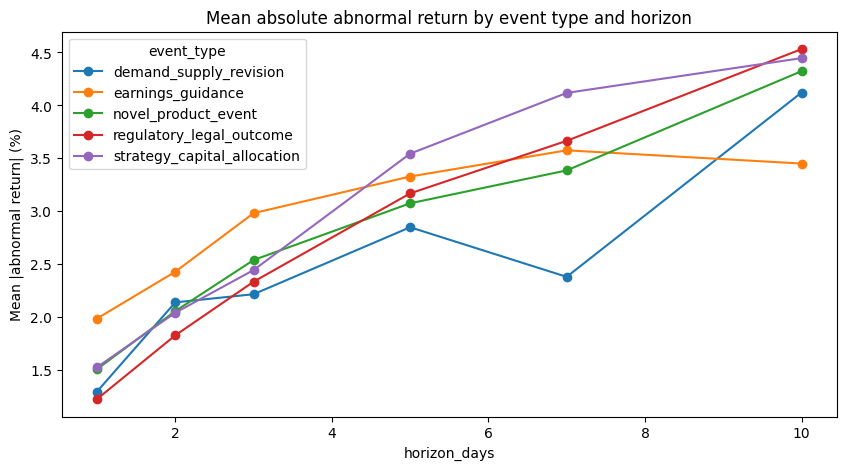

In [12]:
print("Event-return rows by horizon")
display(event_returns["horizon_days"].value_counts().sort_index().rename_axis("horizon_days").reset_index(name="rows"))

pooled_horizon = (
    event_returns
    .groupby("horizon_days")
    .agg(
        n=("abnormal_return", "size"),
        mean_ar_pct=("abnormal_return", lambda s: 100*s.mean()),
        mean_abs_ar_pct=("abnormal_return", lambda s: 100*s.abs().mean()),
        positive_rate_pct=("abnormal_return", lambda s: 100*(s > 0).mean()),
    )
    .reset_index()
)
display(pooled_horizon)

by_type_horizon = (
    event_returns
    .groupby(["event_type", "horizon_days"])
    .agg(
        n=("abnormal_return", "size"),
        mean_ar_pct=("abnormal_return", lambda s: 100*s.mean()),
        mean_abs_ar_pct=("abnormal_return", lambda s: 100*s.abs().mean()),
    )
    .reset_index()
)
display(by_type_horizon)

if plt is not None:
    pivot = by_type_horizon.pivot(index="horizon_days", columns="event_type", values="mean_abs_ar_pct")
    pivot.plot(marker="o", figsize=(10, 5), title="Mean absolute abnormal return by event type and horizon")
    plt.ylabel("Mean |abnormal return| (%)")
    plt.show()


In [13]:
print("Original ticker/event/horizon p-value summary")
display(
    event_summary
    .sort_values(["mean_abnormal_signflip_p", "direction_binomial_p"])
    .head(25)
)


Original ticker/event/horizon p-value summary


,ticker,event_type,horizon_days,n_events,mean_abnormal_return_pct,mean_abnormal_signflip_p,mean_absolute_abnormal_return_pct,direction_agreement_pct,direction_binomial_p
121,NVDA,regulatory_legal_outcome,2,14,-2.122245,0.004200,2.425920,57.142857,0.395264
122,NVDA,regulatory_legal_outcome,3,14,-2.991280,0.007699,3.635369,50.000000,0.604736
146,TSLA,strategy_capital_allocation,3,20,-2.537645,0.008499,3.850076,55.000000,0.411901
120,NVDA,regulatory_legal_outcome,1,14,-0.961583,0.029097,1.242293,64.285714,0.211975
123,NVDA,regulatory_legal_outcome,5,14,-2.827846,0.029797,4.386569,42.857143,0.788025
40,AMZN,regulatory_legal_outcome,7,20,-1.676595,0.050595,3.103351,60.000000,0.251722
87,MSFT,earnings_guidance,5,6,-2.913810,0.058894,3.467312,33.333333,0.890625
68,META,novel_product_event,3,5,-1.467336,0.063094,1.467336,0.000000,1.000000
125,NVDA,regulatory_legal_outcome,10,13,-2.407957,0.068493,4.252152,38.461538,0.866577
105,NVDA,demand_supply_revision,5,8,-2.241879,0.078792,2.774751,37.500000,0.855469


## 8. How bullish/bearish/neutral is classified

The second script turns realised abnormal returns into three labels at the primary horizon.

Default primary horizon:

```text
3 trading days
```

Default threshold:

```text
+0.5% abnormal return or higher  -> bullish
-0.5% abnormal return or lower   -> bearish
otherwise                        -> neutral
```

This label is used as the evaluation target. It is **not** what the LLM sees when producing event facts. The LLM predicts `expected_label` from the headline/event semantics; the realised label comes from post-event abnormal returns.


In [14]:
PRIMARY_HORIZON = int(bull_manifest["primary_horizon"])
RETURN_THRESHOLD = float(bull_manifest["return_threshold"])

def realised_label(ar: float, threshold: float = RETURN_THRESHOLD) -> str:
    if ar > threshold:
        return "bullish"
    if ar < -threshold:
        return "bearish"
    return "neutral"

primary = refined_returns.loc[refined_returns["horizon_days"].eq(PRIMARY_HORIZON)].copy()
primary["event_date"] = pd.to_datetime(primary["event_date"])
primary["recomputed_label"] = primary["abnormal_return"].map(realised_label)

print("Primary horizon:", PRIMARY_HORIZON)
print("Return threshold:", RETURN_THRESHOLD)
print("Check saved realised_label equals recomputed label:")
display(pd.crosstab(primary["realised_label"], primary["recomputed_label"]))

display(primary[["ticker", "event_date", "representative_title", "abnormal_return", "expected_label", "realised_label"]].head(20))


Primary horizon: 3
Return threshold: 0.005
Check saved realised_label equals recomputed label:


recomputed_label,bearish,bullish,neutral
realised_label,,,
bearish,173,0,0
bullish,0,149,0
neutral,0,0,58


,ticker,event_date,representative_title,abnormal_return,expected_label,realised_label
2,AAPL,2023-07-05,"Settlement checks in the mail from Roundup, EpiPen, Zoom, others",-0.001181,neutral,neutral
8,AAPL,2023-07-20,Report: Apple built ‘Apple GPT’ chatbot using internal AI development framework,-0.013894,bullish,bearish
14,AAPL,2023-08-04,"Apple sees sales slump continuing, shares drop 2% despite beating sales expectations",-0.062162,bearish,bearish
20,AAPL,2023-08-29,"Apellis to lay off 25% of staff, trim research in major restructuring",0.022468,bearish,bullish
26,AAPL,2023-09-22,Calix taps Jabil as part of $42B+ broadband manufacturing plan,0.004774,neutral,neutral
32,AAPL,2023-10-30,Apple Looks to Regain Chip Bragging Rights With Trio of M3 Processors,0.003599,bullish,neutral
38,AAPL,2023-11-14,"Spotlight on illegal hiring practices: Apple pays $25M for recruiting, job ad mistakes",0.002671,bearish,neutral
44,AAPL,2023-11-30,Apple announces expanded partnership with Amkor for advanced silicon packaging in the U.S.,-0.004071,bullish,neutral
50,AAPL,2023-12-19,Apple Races to Tweak Software Ahead of Looming US Watch Ban,-0.006495,bearish,bearish
56,AAPL,2024-01-10,Software Glitch Behind Recalled App Could Drastically Increase Insulin Delivery,0.000068,bearish,neutral


In [15]:
def period_name(date):
    d = pd.Timestamp(date).tz_localize(None)
    disc_start, disc_end = map(pd.Timestamp, bull_manifest["discovery"])
    val_start, val_end = map(pd.Timestamp, bull_manifest["validation"])
    test_start, test_end = map(pd.Timestamp, bull_manifest["test"])
    if disc_start <= d <= disc_end:
        return "discovery"
    if val_start <= d <= val_end:
        return "validation"
    if test_start <= d <= test_end:
        return "test"
    return "outside_split"

primary["period"] = primary["event_date"].map(period_name)

print("Realised label distribution by period")
display(pd.crosstab(primary["period"], primary["realised_label"], margins=True))

print("LLM expected label distribution by period")
display(pd.crosstab(primary["period"], primary["expected_label"], margins=True))

print("Expected vs realised label at primary horizon")
display(pd.crosstab(primary["expected_label"], primary["realised_label"], margins=True))


Realised label distribution by period


realised_label,bearish,bullish,neutral,All
period,,,,
discovery,86,62,29,177
test,33,26,4,63
validation,54,61,25,140
All,173,149,58,380


LLM expected label distribution by period


expected_label,bearish,bullish,neutral,All
period,,,,
discovery,48,81,48,177
test,13,26,24,63
validation,27,74,39,140
All,88,181,111,380


Expected vs realised label at primary horizon


realised_label,bearish,bullish,neutral,All
expected_label,,,,
bearish,37,40,11,88
bullish,83,75,23,181
neutral,53,34,24,111
All,173,149,58,380


## 9. Neutral threshold sensitivity

The current threshold is only `0.5%`. MAG7 stocks often move more than this over 3 trading days, so the neutral class can become very small.

This section recalculates bullish/bearish/neutral labels under wider thresholds. No GPU is needed.


,horizon_days,threshold_pct,n,bullish_pct,bearish_pct,neutral_pct
0,1,0.5,381,33.858268,38.582677,27.559055
1,1,1.0,381,20.997375,25.459318,53.543307
2,1,1.5,381,14.435696,18.635171,66.929134
3,1,2.0,381,9.973753,12.073491,77.952756
4,1,3.0,381,5.774278,4.724409,89.501312
5,2,0.5,381,37.795276,42.519685,19.685039
6,2,1.0,381,27.296588,33.595801,39.107612
7,2,1.5,381,20.209974,29.396325,50.393701
8,2,2.0,381,14.960630,20.734908,64.304462
9,2,3.0,381,8.136483,11.023622,80.839895


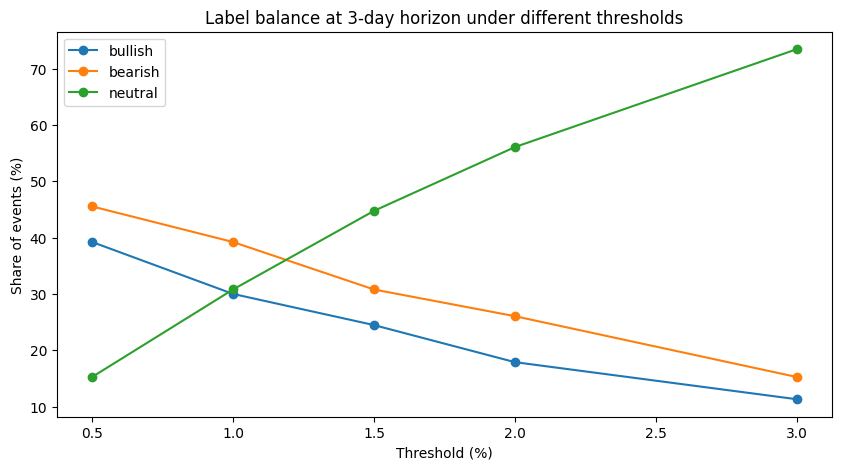

In [16]:
thresholds = [0.005, 0.01, 0.015, 0.02, 0.03]
rows = []
for h, g_h in refined_returns.groupby("horizon_days"):
    for th in thresholds:
        labels = g_h["abnormal_return"].map(lambda x: realised_label(float(x), th))
        rows.append({
            "horizon_days": h,
            "threshold_pct": 100*th,
            "n": len(labels),
            "bullish_pct": 100*(labels == "bullish").mean(),
            "bearish_pct": 100*(labels == "bearish").mean(),
            "neutral_pct": 100*(labels == "neutral").mean(),
        })
threshold_sensitivity = pd.DataFrame(rows)
display(threshold_sensitivity)

if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    subset = threshold_sensitivity.loc[threshold_sensitivity["horizon_days"].eq(PRIMARY_HORIZON)]
    ax.plot(subset["threshold_pct"], subset["bullish_pct"], marker="o", label="bullish")
    ax.plot(subset["threshold_pct"], subset["bearish_pct"], marker="o", label="bearish")
    ax.plot(subset["threshold_pct"], subset["neutral_pct"], marker="o", label="neutral")
    ax.set_title(f"Label balance at {PRIMARY_HORIZON}-day horizon under different thresholds")
    ax.set_xlabel("Threshold (%)")
    ax.set_ylabel("Share of events (%)")
    ax.legend()
    plt.show()


## 10. Second-pass LLM refinement

The second pass does not classify all 63k headlines again. It only refines the 381 event-study episodes.

It extracts structured fields:

- `include_candidate`
- `expected_label`: bullish / bearish / neutral
- `event_subtype`
- `valuation_channel`
- `materiality_strength`
- `novelty`
- `rationale`

The idea is:

```text
LLM = semantic parser
LTN/rules = structured reasoning layer
```

The LLM is not given past market context in the prompt. It is asked to judge the event semantics from the headline/event description.


In [17]:
print("Second-pass refinement schema")
display(refinements.head(10))

for col in ["include_candidate", "expected_label", "event_subtype", "valuation_channel", "materiality_strength", "novelty"]:
    print("\n", col)
    display(refinements[col].value_counts(dropna=False).head(30).rename_axis(col).reset_index(name="n"))


Second-pass refinement schema


,event_id,ticker,time_published,event_date,event_type,direction,event_key,mechanism,representative_title,article_count,include_candidate,expected_label,event_subtype,valuation_channel,materiality_strength,novelty,rationale,raw_refinement
0,948fafb090080ef59724884465792a9066c6be1e,AAPL,2023-07-03 23:40:57+00:00,2023-07-05,regulatory_legal_outcome,positive,Roundup_EpiPen_Settlement,cash_inflow_from_settlements,"Settlement checks in the mail from Roundup, EpiPen, Zoom, others",1,False,neutral,lawsuit_settlement,legal_liability,medium,material_update,Settlements reduce legal liabilities but may impact financials.,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""neutral"",\n ""event_subtype"": ""lawsuit_settlement"",\n ""valuation_channel"": ""legal_liability"",\n ""materiality_st..."
1,c7b4d791c57de84c18f3db39de4c73b82c7eb44b,AAPL,2023-07-19 22:53:14+00:00,2023-07-20,novel_product_event,positive,internal_ai_development,development_of_chatbot_using_internal_ai_framework,Report: Apple built ‘Apple GPT’ chatbot using internal AI development framework,1,True,bullish,product_launch,product_adoption,high,new_event,Development of an AI chatbot could enhance Apple’s product offerings and user engagement.,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""bullish"",\n ""event_subtype"": ""product_launch"",\n ""valuation_channel"": ""product_adoption"",\n ""materiality_stren..."
2,b996d4f12fe991428fbf6de07234636c2f9c901e,AAPL,2023-08-04 06:26:00+00:00,2023-08-04,demand_supply_revision,negative,sales_slump_continuing,reduction_in_demand,"Apple sees sales slump continuing, shares drop 2% despite beating sales expectations",1,True,bearish,demand_decrease,revenue_demand,high,material_update,Continuing sales slump despite beating expectations,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""bearish"",\n ""event_subtype"": ""demand_decrease"",\n ""valuation_channel"": ""revenue_demand"",\n ""materiality_streng..."
3,4324f378e029a39d35f5fdbe1c8ce4b6d2c43b92,AAPL,2023-08-29 00:00:00+00:00,2023-08-29,regulatory_legal_outcome,negative,staff_restructuring,layoff_and_research_trim,"Apellis to lay off 25% of staff, trim research in major restructuring",1,True,bearish,layoffs_cost_cutting,cost_margin,high,material_update,Cost-cutting measures often signal financial pressure.,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""bearish"",\n ""event_subtype"": ""layoffs_cost_cutting"",\n ""valuation_channel"": ""cost_margin"",\n ""materiality_stre..."
4,1f9f226de9ec4ae7026bbe90c39ecb365d7927bc,AAPL,2023-09-22 00:00:00+00:00,2023-09-22,strategy_capital_allocation,positive,manufacturing_partnership,outsourcing to Jabil for manufacturing,Calix taps Jabil as part of $42B+ broadband manufacturing plan,1,False,neutral,partnership_customer_deal,unclear,medium,material_update,Outsourcing manufacturing to Jabil is a strategic move but its impact on valuation is unclear.,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""neutral"",\n ""event_subtype"": ""partnership_customer_deal"",\n ""valuation_channel"": ""unclear"",\n ""materiality_str..."
5,24e3bdc1e2cbcd2dfded014f2c1877aa9d7631f6,AAPL,2023-10-29 12:45:00+00:00,2023-10-30,strategy_capital_allocation,positive,M3_Processor_Release,Investment in chip manufacturing and design,Apple Looks to Regain Chip Bragging Rights With Trio of M3 Processors,1,True,bullish,product_launch,cost_margin,high,new_event,Investment in chip manufacturing and design could enhance product competitiveness.,"```json\n{\n ""include_candidate"": true,\n ""expected_label"": ""bullish"",\n ""event_subtype"": ""product_launch"",\n ""valuation_channel"": ""cost_margin"",\n ""materiality_strength"":..."
6,6d41160e3b241fa4b7d2e128b5abaa67cbc3a299,AAPL,2023-11-14 00:00:00+00:00,2023-11-14,regulatory_legal_outcome,negative,legal_fine_recruiting_mistakes,payment_of_legal_fine,"Spotlight on illegal hiring practices: Apple pays $25M for recruiting, job ad mistakes",1,True,


 include_candidate


,include_candidate,n
0,True,261
1,False,120



 expected_label


...

,valuation_channel,n
0,revenue_demand,116
1,legal_liability,74
2,unclear,51
3,product_adoption,50
4,cost_margin,30
5,capex_cashflow,17
6,financing_liquidity,16
7,regulatory_risk,15
8,competitive_position,8
9,management_strategy,4



 materiality_strength


,materiality_strength,n
0,high,235
1,medium,141
2,low,5



 novelty


,novelty,n
0,material_update,241
1,new_event,132
2,repeat_coverage,7
3,unclear,1


In [18]:
print("Examples marked candidate")
display(
    refinements.loc[refinements["include_candidate"],
                    ["ticker", "event_date", "representative_title", "event_type", "expected_label", "event_subtype", "valuation_channel", "materiality_strength", "novelty", "rationale"]]
    .sample(min(15, int(refinements["include_candidate"].sum())), random_state=12)
)

print("Examples marked neutral / excluded")
display(
    refinements.loc[~refinements["include_candidate"],
                    ["ticker", "event_date", "representative_title", "event_type", "expected_label", "event_subtype", "valuation_channel", "materiality_strength", "novelty", "rationale"]]
    .sample(min(15, int((~refinements["include_candidate"]).sum())), random_state=12)
)


Examples marked candidate


,ticker,event_date,representative_title,event_type,expected_label,event_subtype,valuation_channel,materiality_strength,novelty,rationale
123,GOOGL,2024-09-26,"Alphabet, Goldman Sachs and others to settle charges over late filings, SEC says",regulatory_legal_outcome,bearish,fine_or_penalty,legal_liability,high,material_update,Regulatory fine increases legal liability.
134,GOOGL,2025-05-27,"Alphabet Inc: in 10 years, we'll laugh at these valuations, unless",regulatory_legal_outcome,bullish,regulatory_threat,revenue_demand,high,material_update,Market perceives long-term positive outlook despite current regulatory concerns.
272,NVDA,2023-12-19,Folsom Intel Campus To Cut 235 More Jobs By End Of The Month,regulatory_legal_outcome,bearish,layoffs_cost_cutting,cost_margin,high,material_update,Cost reduction through job cuts may pressure margins.
158,META,2023-07-27,Federal lawsuit claims AMC illegally shared customers' information with Facebook,regulatory_legal_outcome,bearish,lawsuit_filed,legal_liability,high,new_event,Legal action can increase liability risks.
131,GOOGL,2025-03-21,Quest Diagnostics Strikes Generative AI Partnership with Google Cloud,strategy_capital_allocation,bullish,partnership_customer_deal,product_adoption,high,new_event,Strategic partnership enhances product offerings.
45,AAPL,2026-02-20,Opendoor Technologies jumps after posting better-than-expected Q4 results,earnings_guidance,bullish,earnings_beat,revenue_demand,high,material_update,Q4 results better than expected
164,META,2024-02-15,Meta Licenses New Haptic Technology,novel_product_event,bullish,product_launch,product_adoption,medium,new_event,"Introduces new haptic technology, potentially enhancing product offerings."
147,GOOGL,2026-01-06,Vistra Energy to Acquire Cogentrix Natural Gas Portfolio,strategy_capital_allocation,bullish,acquisition,capex_cashflow,high,material_update,Strategic acquisition enhances operational scale and diversification.
5,AAPL,2023-10-30,Apple Looks to Regain Chip Bragging Rights With Trio of M3 Processors,strategy_capital_allocation,bullish,product_launch,cost_margin,high,new_event,Investment in chip manufacturing and design could enhance product competitiveness.
296,NVDA,2025-02-05,Supermicro Ramps Full Production of NVIDIA Blackwell Rack-Scale Solutions with NVIDIA HGX B200,novel_product_event,bullish,product_launch,product_adoption,high,new_event,Enhances product lineup and adoption


Examples marked neutral / excluded


,ticker,event_date,representative_title,event_type,expected_label,event_subtype,valuation_channel,materiality_strength,novelty,rationale
94,AMZN,2025-10-13,"Amazon to hire 250,000 workers during holiday season for third straight year - MarketScreener",strategy_capital_allocation,neutral,acquisition,unclear,medium,material_update,Increased hiring for the holiday season is a routine operational decision.
282,NVDA,2024-06-06,Core Scientific rejects CoreWeave acquisition offer,regulatory_legal_outcome,neutral,acquisition,unclear,medium,material_update,The rejection of an acquisition offer does not provide clear information on the company's valuation or risk outlook.
86,AMZN,2025-05-22,Willard Retail takes over retail leasing at Potomac Yard shopping center,strategy_capital_allocation,neutral,acquisition,unclear,medium,material_update,Real estate acquisition may provide long-term benefits but current impact is uncertain.
304,NVDA,2025-06-18,Texas Instruments commits $60B to domestic chip manufacturing,strategy_capital_allocation,neutral,major_capex,capex_cashflow,high,material_update,Significant capital investment in chip manufacturing may improve long-term competitiveness but has immediate cash flow implications.
224,MSFT,2024-09-06,"In $1.9B deal, Salesforce buys data backup company Own",strategy_capital_allocation,neutral,acquisition,capex_cashflow,high,material_update,Acquisition may enhance data security but requires significant cash outlay.
157,META,2023-06-30,Cognizant to lay off nearly 60 working in Facebook's North Austin tower,regulatory_legal_outcome,neutral,layoffs_cost_cutting,unclear,medium,repeat_coverage,Layoffs may reduce costs but could also signal broader industry challenges.
215,MSFT,2024-03-28,A new product allows 5x leveraged bets on the Magnificent Seven. Traders should be wary.,novel_product_event,bearish,product_launch,unclear,medium,new_event,Increased risk due to high leverage on a volatile stock group.
4,AAPL,2023-09-22,Calix taps Jabil as part of $42B+ broadband manufacturing plan,strategy_capital_allocation,neutral,partnership_customer_deal,unclear,medium,material_update,Outsourcing manufacturing to Jabil is a strategic move but its impact on valuation is unclear.
293,NVDA,2024-12-13,SK Telecom invests $3 million in AI startup Twelve Labs,strategy_capital_allocation,neutral,other,unclear,medium,material_update,Investment in an AI startup may have long-term benefits but does not immediately impact NVDA's core business.
34,AAPL,2025-07-29,Trademark Claims Against Peloton Over Use of ‘Bike+’ Fail,regulatory_legal_outcome,neutral,lawsuit_settlement,legal_liability,medium,material_update,The failure of trademark claims reduces legal liabilities but does not significantly impact Apple's core business.


## 11. LTN rule mining: what is happening?

The LTN stage uses structured features from the LLM/refinement stage and learns soft rules over them.

Examples of rule conditions:

```text
event_type=earnings_guidance & materiality_strength=high
event_type=demand_supply_revision
event_type=strategy_capital_allocation & direction=negative
```

Each condition is treated as a rule antecedent. The model learns a soft truth/confidence for mapping that antecedent to one of:

```text
bullish / bearish / neutral
```

The training period is discovery only:

```text
2023-01-01 to 2024-12-31
```

Rules are then checked on validation:

```text
2025-01-01 to 2025-12-31
```

Only validation-passed rules are evaluated on the final holdout:

```text
2026-01-01 to 2026-06-01
```

This matters because otherwise the rules would be tuned directly to the final test period.


In [19]:
print("Top discovered LTN rules")
display(
    rules_discovery
    .sort_values(["rule_score", "discovery_n"], ascending=False)
    .head(30)
)

print("Validation results for discovered rules")
display(
    rules_validation
    .sort_values(["validation_accuracy_pct", "validation_n"], ascending=False)
    .head(30)
)


Top discovered LTN rules


,condition,rule_label,ltn_rule_truth,empirical_rule_accuracy,rule_score,ltn_final_loss,discovery_n,discovery_accuracy_pct,discovery_mean_ar_pct,discovery_mean_abs_ar_pct,discovery_bullish_rate_pct,discovery_bearish_rate_pct,discovery_neutral_rate_pct,discovery_directional_agreement_p,discovery_aligned_mean_pct,discovery_aligned_signflip_p
0,materiality_strength=high & expected_label=bullish,bearish,0.977034,0.557143,3.401447,0.63082,70,55.714286,-0.163259,2.601811,32.857143,55.714286,11.428571,0.201482,0.163259,0.355364
1,valuation_channel=revenue_demand & expected_label=bullish,bullish,0.991390,0.500000,3.359915,0.63082,30,50.000000,0.324122,2.605574,50.000000,46.666667,3.333333,0.572232,0.324122,0.309669
2,direction=positive & valuation_channel=revenue_demand,bullish,0.985265,0.500000,3.348592,0.63082,30,50.000000,0.308530,2.589982,50.000000,46.666667,3.333333,0.572232,0.308530,0.315368
3,materiality_strength=medium & expected_label=neutral,bearish,0.981049,0.500000,3.321556,0.63082,44,50.000000,-0.705437,2.521520,20.454545,50.000000,29.545455,0.559802,0.705437,0.111189
4,novelty=material_update & expected_label=bullish,bearish,0.955615,0.615385,3.320963,0.63082,39,61.538462,-0.817960,2.249891,28.205128,61.538462,10.256410,0.099795,0.817960,0.037896
5,event_type=strategy_capital_allocation & materiality_strength=medium,bearish,0.992715,0.571429,3.205282,0.63082,21,57.142857,-0.974438,2.823415,28.571429,57.142857,14.285714,0.331812,0.974438,0.137686
6,valuation_channel=revenue_demand & materiality_strength=high,bearish,0.681634,0.515152,3.130009,0.63082,33,51.515152,-0.296882,2.799670,42.424242,51.515152,6.060606,0.500000,0.296882,0.333367
7,event_subtype=ai_infrastructure_spend & materiality_strength=high,bearish,0.988917,0.857143,3.079393,0.63082,7,85.714286,-0.821230,3.087562,14.285714,85.714286,0.000000,0.062500,0.821230,0.280972
8,event_subtype=ai_infrastructure_spend & valuation_channel=cost_margin,bearish,0.988917,0.857143,3.079393,0.63082,7,85.714286,-0.821230,3.087562,14.285714,85.714286,0.000000,0.062500,0.821230,0.280972
9,event_type=novel_product_event & materiality_strength=high,bearish,0.995027,0.666667,3.061693,0.63082,12,66.666667,-0.403535,3.263536,25.000000,66.666667,8.333333,0.193848,0.403535,0.378562


Validation results for discovered rules


,condition,rule_label,validation_n,validation_accuracy_pct,validation_mean_ar_pct,validation_mean_abs_ar_pct,validation_bullish_rate_pct,validation_bearish_rate_pct,validation_neutral_rate_pct,validation_directional_agreement_p,validation_aligned_mean_pct,validation_aligned_signflip_p
32,event_type=demand_supply_revision & expected_label=bullish,bearish,7,71.428571,-2.347903,3.080741,14.285714,71.428571,14.285714,0.226562,2.347903,0.081892
10,event_type=strategy_capital_allocation & direction=negative,bearish,3,66.666667,-1.113504,2.563710,33.333333,66.666667,0.000000,0.500000,1.113504,0.370663
37,valuation_channel=product_adoption & materiality_strength=medium,bearish,3,66.666667,-2.247673,2.509728,0.000000,66.666667,33.333333,0.500000,2.247673,0.246775
15,event_type=demand_supply_revision & novelty=material_update,bearish,7,57.142857,-2.460873,2.809423,14.285714,57.142857,28.571429,0.500000,2.460873,0.045795
28,event_type=demand_supply_revision & direction=positive,bearish,7,57.142857,-1.206386,2.260947,28.571429,57.142857,14.285714,0.500000,1.206386,0.206079
30,direction=positive & valuation_channel=cost_margin,bearish,7,57.142857,-1.383870,1.758029,28.571429,57.142857,14.285714,0.500000,1.383870,0.095090
31,valuation_channel=cost_margin & expected_label=bullish,bearish,7,57.142857,-1.383870,1.758029,28.571429,57.142857,14.285714,0.500000,1.383870,0.095090
22,event_type=earnings_guidance & materiality_strength=high,bullish,16,56.250000,2.006401,3.088238,56.250000,25.000000,18.750000,0.401810,2.006401,0.045995
24,event_type=demand_supply_revision,bearish,9,55.555556,-1.746743,2.566958,22.222222,55.555556,22.222222,0.500000,1.746743,0.082492
17,event_subtype=acquisition & expected_label=bullish,bearish,4,50.000000,-1.235084,3.167352,50.000000,50.000000,0.000000,0.687500,1.235084,0.441456


In [20]:
def reconstruct_selected_rules(discovery: pd.DataFrame, validation: pd.DataFrame, min_validation_events: int = 3) -> pd.DataFrame:
    merged = discovery.merge(validation, on=["condition", "rule_label"], how="inner")
    keep = merged["validation_n"].ge(min_validation_events) & merged["validation_accuracy_pct"].ge(50)
    directional = merged["rule_label"].isin(["bullish", "bearish"])
    keep &= (~directional) | merged["validation_aligned_mean_pct"].fillna(0).gt(0)
    return merged.loc[keep].sort_values(["rule_score", "validation_n"], ascending=False).reset_index(drop=True)

selected_rules = reconstruct_selected_rules(rules_discovery, rules_validation)
print("Selected validated rules:", len(selected_rules))
display(selected_rules)


Selected validated rules: 10


,condition,rule_label,ltn_rule_truth,empirical_rule_accuracy,rule_score,ltn_final_loss,discovery_n,discovery_accuracy_pct,discovery_mean_ar_pct,discovery_mean_abs_ar_pct,discovery_bullish_rate_pct,discovery_bearish_rate_pct,discovery_neutral_rate_pct,discovery_directional_agreement_p,discovery_aligned_mean_pct,discovery_aligned_signflip_p,validation_n,validation_accuracy_pct,validation_mean_ar_pct,validation_mean_abs_ar_pct,validation_bullish_rate_pct,validation_bearish_rate_pct,validation_neutral_rate_pct,validation_directional_agreement_p,validation_aligned_mean_pct,validation_aligned_signflip_p
0,event_type=strategy_capital_allocation & direction=negative,bearish,0.994818,0.833333,3.028151,0.63082,6,83.333333,-3.309709,3.560196,16.666667,83.333333,0.000000,0.109375,3.309709,0.032297,3,66.666667,-1.113504,2.563710,33.333333,66.666667,0.000000,0.500000,1.113504,0.370663
1,event_type=demand_supply_revision & novelty=material_update,bearish,0.994071,0.900000,2.940333,0.63082,10,90.000000,-1.941323,2.138786,10.000000,90.000000,0.000000,0.010742,1.941323,0.003100,7,57.142857,-2.460873,2.809423,14.285714,57.142857,28.571429,0.500000,2.460873,0.045795
2,event_subtype=acquisition & expected_label=bullish,bearish,0.949886,0.666667,2.916553,0.63082,9,66.666667,-1.086613,3.613533,33.333333,66.666667,0.000000,0.253906,1.086613,0.258874,4,50.000000,-1.235084,3.167352,50.000000,50.000000,0.000000,0.687500,1.235084,0.441456
3,event_type=earnings_guidance & materiality_strength=high,bullish,0.994120,0.714286,2.741056,0.63082,7,71.428571,0.669420,2.397952,71.428571,28.571429,0.000000,0.226562,0.669420,0.276072,16,56.250000,2.006401,3.088238,56.250000,25.000000,18.750000,0.401810,2.006401,0.045995
4,event_type=demand_supply_revision,bearish,0.811902,0.769231,2.708663,0.63082,13,76.923077,-1.397551,2.082589,15.384615,76.923077,7.692308,0.046143,1.397551,0.019298,9,55.555556,-1.746743,2.566958,22.222222,55.555556,22.222222,0.500000,1.746743,0.082492
5,event_type=demand_supply_revision & direction=positive,bearish,0.941971,0.800000,2.670224,0.63082,10,80.000000,-1.091672,1.784759,10.000000,80.000000,10.000000,0.054688,1.091672,0.044796,7,57.142857,-1.206386,2.260947,28.571429,57.142857,14.285714,0.500000,1.206386,0.206079
6,direction=positive & valuation_channel=cost_margin,bearish,0.679793,0.800000,2.592786,0.63082,10,80.000000,-0.680560,2.338978,10.000000,80.000000,10.000000,0.054688,0.680560,0.291271,7,57.142857,-1.383870,1.758029,28.571429,57.142857,14.285714,0.500000,1.383870,0.095090
7,valuation_channel=cost_margin & expected_label=bullish,bearish,0.679793,0.800000,2.592786,0.63082,10,80.000000,-0.680560,2.338978,10.000000,80.000000,10.000000,0.054688,0.680560,0.291271,7,57.142857,-1.383870,1.758029,28.571429,57.142857,14.285714,0.500000,1.383870,0.095090
8,event_type=demand_supply_revision & expected_label=bullish,bearish,0.750368,0.777778,2.450887,0.63082,9,77.777778,-1.098126,1.868223,11.111111,77.777778,11.111111,0.089844,1.098126,0.057194,7,71.428571,-2.347903,3.080741,14.285714,71.428571,14.285714,0.226562,2.347903,0.081892
9,valuation_channel=product_adoption & materiality_strength=medium,bearish,0.989742,0.571429,2.114364,0.63082,7,57.142857,-0.449395,0.959581,14.285714,57.142857,28.571429,0.500000,0.449395,0.160184,3,66.666667,-2.247673,2.509728,0.000000,66.666667,33.333333,0.500000,2.247673,0.246775


## 12. How accuracy is measured

For each event at the primary horizon:

```text
predicted label = LLM expected_label or LTN rule label
realised label  = abnormal return bucket
accuracy        = predicted label == realised label
```

For directional rules only (`bullish` or `bearish`), the notebook also checks aligned abnormal return:

```text
if prediction is bullish: aligned return = abnormal_return
if prediction is bearish: aligned return = -abnormal_return
```

If the rule is useful, the aligned mean should be positive.

The p-values in the saved summaries are:

- `directional_agreement_p`: binomial test against 50% agreement for directional predictions
- `aligned_signflip_p`: random sign-flip test for whether aligned mean return is stronger than random sign assignment


In [21]:
print("Discovery summary")
display(summary_discovery)

print("Validation summary")
display(summary_validation)

print("Held-out test summary")
display(summary_test)


Discovery summary


,group,discovery_n,discovery_accuracy_pct,discovery_mean_ar_pct,discovery_mean_abs_ar_pct,discovery_bullish_rate_pct,discovery_bearish_rate_pct,discovery_neutral_rate_pct,discovery_directional_agreement_p,discovery_aligned_mean_pct,discovery_aligned_signflip_p
0,all_events_baseline,177,NaN,-0.303731,2.435968,35.028249,48.587571,16.384181,NaN,NaN,NaN
1,llm_include_candidate,124,NaN,-0.123606,2.456196,39.516129,48.387097,12.096774,NaN,NaN,NaN
2,llm_expected_label,177,33.333333,-0.303731,2.435968,35.028249,48.587571,16.384181,0.999622,-0.036405,0.549545
3,rule_matched,51,72.549020,-1.013704,2.479935,25.490196,66.666667,7.843137,0.000885,1.197466,0.004800
4,rule_bullish,7,71.428571,0.669420,2.397952,71.428571,28.571429,0.000000,0.226562,0.669420,0.276072
5,rule_bearish,44,72.727273,-1.281474,2.492978,18.181818,72.727273,9.090909,0.001829,1.281474,0.005699
6,rule_neutral,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Validation summary


,group,validation_n,validation_accuracy_pct,validation_mean_ar_pct,validation_mean_abs_ar_pct,validation_bullish_rate_pct,validation_bearish_rate_pct,validation_neutral_rate_pct,validation_directional_agreement_p,validation_aligned_mean_pct,validation_aligned_signflip_p
0,all_events_baseline,140,NaN,0.059116,2.337252,43.571429,38.571429,17.857143,NaN,NaN,NaN
1,llm_include_candidate,99,NaN,0.189920,2.538024,46.464646,37.373737,16.161616,NaN,NaN,NaN
2,llm_expected_label,140,37.857143,0.059116,2.337252,43.571429,38.571429,17.857143,0.883850,0.169129,0.329867
3,rule_matched,42,57.142857,-0.198315,2.683580,38.095238,45.238095,16.666667,0.220400,1.727002,0.001000
4,rule_bullish,16,56.250000,2.006401,3.088238,56.250000,25.000000,18.750000,0.401810,2.006401,0.045995
5,rule_bearish,26,57.692308,-1.555063,2.434559,26.923077,57.692308,15.384615,0.278599,1.555063,0.007199
6,rule_neutral,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Held-out test summary


,group,test_n,test_accuracy_pct,test_mean_ar_pct,test_mean_abs_ar_pct,test_bullish_rate_pct,test_bearish_rate_pct,test_neutral_rate_pct,test_directional_agreement_p,test_aligned_mean_pct,test_aligned_signflip_p
0,all_events_baseline,63,NaN,-0.420164,2.667088,41.269841,52.380952,6.349206,NaN,NaN,NaN
1,llm_include_candidate,37,NaN,-0.231509,2.893285,43.243243,54.054054,2.702703,NaN,NaN,NaN
2,llm_expected_label,63,38.095238,-0.420164,2.667088,41.269841,52.380952,6.349206,0.374629,0.688883,0.126787
3,rule_matched,20,60.000000,0.041309,2.408471,50.000000,50.000000,0.000000,0.251722,0.892232,0.084992
4,rule_bullish,6,66.666667,1.555902,3.469843,66.666667,33.333333,0.000000,0.343750,1.555902,0.168183
5,rule_bearish,14,57.142857,-0.607802,1.953597,42.857143,57.142857,0.000000,0.395264,0.607802,0.165783
6,rule_neutral,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,group,discovery_n,discovery_accuracy_pct,discovery_mean_ar_pct,discovery_mean_abs_ar_pct,discovery_bullish_rate_pct,discovery_bearish_rate_pct,discovery_neutral_rate_pct,discovery_directional_agreement_p,discovery_aligned_mean_pct,discovery_aligned_signflip_p,period,validation_n,validation_accuracy_pct,validation_mean_ar_pct,validation_mean_abs_ar_pct,validation_bullish_rate_pct,validation_bearish_rate_pct,validation_neutral_rate_pct,validation_directional_agreement_p,validation_aligned_mean_pct,validation_aligned_signflip_p,test_n,test_accuracy_pct,test_mean_ar_pct,test_mean_abs_ar_pct,test_bullish_rate_pct,test_bearish_rate_pct,test_neutral_rate_pct,test_directional_agreement_p,test_aligned_mean_pct,test_aligned_signflip_p
0,all_events_baseline,177.0,NaN,-0.303731,2.435968,35.028249,48.587571,16.384181,NaN,NaN,NaN,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,llm_include_candidate,124.0,NaN,-0.123606,2.456196,39.516129,48.387097,12.096774,NaN,NaN,NaN,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,llm_expected_label,177.0,33.333333,-0.303731,2.435968,35.028249,48.587571,16.384181,0.999622,-0.036405,0.549545,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,rule_matched,51.0,72.549020,-1.013704,2.479935,25.490196,66.666667,7.843137,0.000885,1.197466,0.004800,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rule_bullish,7.0,71.428571,0.669420,2.397952,71.428571,28.571429,0.000000,0.226562,0.669420,0.276072,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,rule_bearish,44.0,72.727273,-1.281474,2.492978,18.181818,72.727273,9.090909,0.001829,1.281474,0.005699,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rule_neutral,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,discovery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,all_events_baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,validation,140.0,NaN,0.059116,2.337252,43.571429,38.571429,17.857143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,llm_include_candidate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,validation,99.0,NaN,0.189920,2.538024,46.464646,37.373737,16.161616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,llm_expected_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,validation,140.0,37.857143,0.059116,2.337252,43.571429,38.571429,17.857143,0.883850,0.169129,0.329867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


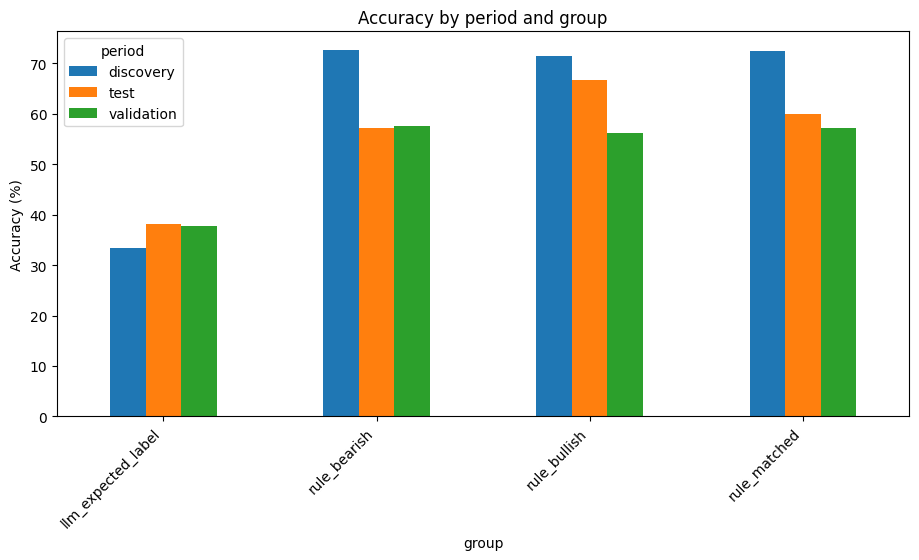

In [22]:
summary_compare = pd.concat([
    summary_discovery.assign(period="discovery"),
    summary_validation.assign(period="validation"),
    summary_test.assign(period="test"),
], ignore_index=True)

display(summary_compare)

if plt is not None:
    acc_cols = [c for c in summary_compare.columns if c.endswith("_accuracy_pct")]
    rows = []
    for _, row in summary_compare.iterrows():
        period = row["period"]
        acc_col = f"{period}_accuracy_pct"
        if acc_col in row:
            rows.append({"period": period, "group": row["group"], "accuracy_pct": row[acc_col]})
    acc_df = pd.DataFrame(rows).dropna()
    if not acc_df.empty:
        pivot = acc_df.pivot(index="group", columns="period", values="accuracy_pct")
        pivot.plot(kind="bar", figsize=(11, 5), title="Accuracy by period and group")
        plt.ylabel("Accuracy (%)")
        plt.xticks(rotation=45, ha="right")
        plt.show()


## 13. Apply selected rules to inspect individual test events

This section shows exactly which held-out events were matched by a selected rule and whether the rule was correct.


In [23]:
def match_condition(df: pd.DataFrame, condition: str) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for part in condition.split(" & "):
        col, value = part.split("=", 1)
        mask &= df[col].astype(str).eq(value)
    return mask

def apply_selected_rules(df: pd.DataFrame, rules: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["rule_prediction"] = "no_rule"
    out["matched_rule"] = ""
    for _, rule in rules.sort_values("rule_score", ascending=False).iterrows():
        m = match_condition(out, rule["condition"]) & out["rule_prediction"].eq("no_rule")
        out.loc[m, "rule_prediction"] = rule["rule_label"]
        out.loc[m, "matched_rule"] = rule["condition"]
    out["rule_correct"] = out["rule_prediction"].eq(out["realised_label"])
    out.loc[out["rule_prediction"].eq("no_rule"), "rule_correct"] = np.nan
    return out

test_start, test_end = map(pd.Timestamp, bull_manifest["test"])
test_primary = primary.loc[primary["event_date"].between(test_start, test_end)].copy()
test_applied = apply_selected_rules(test_primary, selected_rules)

print("Rule matched test events")
display(
    test_applied.loc[test_applied["rule_prediction"].ne("no_rule"),
                     ["ticker", "event_date", "representative_title", "event_type", "event_subtype", "valuation_channel",
                      "expected_label", "realised_label", "abnormal_return", "rule_prediction", "rule_correct", "matched_rule"]]
    .sort_values(["rule_correct", "event_date"], ascending=[True, True])
)

print("Unmatched test events")
display(
    test_applied.loc[test_applied["rule_prediction"].eq("no_rule"),
                     ["ticker", "event_date", "representative_title", "event_type", "event_subtype", "valuation_channel",
                      "expected_label", "realised_label", "abnormal_return"]]
    .head(50)
)


Rule matched test events


C:\Users\kiera\AppData\Local\Temp\ipykernel_12636\2811145882.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  out.loc[out["rule_prediction"].eq("no_rule"), "rule_correct"] = np.nan


,ticker,event_date,representative_title,event_type,event_subtype,valuation_channel,expected_label,realised_label,abnormal_return,rule_prediction,rule_correct,matched_rule
881,GOOGL,2026-01-06,Vistra Energy to Acquire Cogentrix Natural Gas Portfolio,strategy_capital_allocation,acquisition,capex_cashflow,bullish,bullish,0.013407,bearish,False,event_subtype=acquisition & expected_label=bullish
593,AMZN,2026-01-07,"Post-Holiday Retail Spending Falls Average of 22.4%, but Declines Getting Smaller in 2020s",demand_supply_revision,demand_decrease,revenue_demand,neutral,bullish,0.023516,bearish,False,event_type=demand_supply_revision & novelty=material_update
2230,TSLA,2026-01-29,Tesla Posts Fourth-Quarter Profit That Beats Expectations,earnings_guidance,earnings_beat,revenue_demand,bullish,bearish,-0.024767,bullish,False,event_type=earnings_guidance & materiality_strength=high
1907,NVDA,2026-02-17,IRDM Q4 Deep Dive: New Technology Drives Strategic Transition Amid Flat Revenue,strategy_capital_allocation,major_capex,unclear,neutral,bullish,0.021910,bearish,False,event_type=strategy_capital_allocation & direction=negative
905,GOOGL,2026-03-11,Liberty Broadband revises Charter (NASDAQ: CHTR) stake to 32.4% in 13D,strategy_capital_allocation,other,unclear,neutral,bullish,0.005028,bearish,False,event_type=strategy_capital_allocation & direction=negative
617,AMZN,2026-03-12,Amazon To Build Giant $750 Million Robotics Fulfilment Centre In Queensland,strategy_capital_allocation,major_capex,cost_margin,bullish,bullish,0.014653,bearish,False,direction=positive & valuation_channel=cost_margin
1555,MSFT,2026-05-08,BlackLine (NASDAQ: BL) lifts Q1 2026 revenue to $183.2M and boosts profit,earnings_guidance,guidance_raise,revenue_demand,neutral,bearish,-0.032651,bullish,False,event_type=earnings_guidance & materiality_strength=high
1561,MSFT,2026-05-26,"Northwestern Mutual Wealth Management Co. Sells 36,221 Shares of The Progressive Corporation $PGR",strategy_capital_allocation,other,unclear,neutral,bullish,0.015692,bearish,False,event_type=strategy_capital_allocation & direction=negative
254,AAPL,2026-01-02,Apple Quietly Pulls Back on Vision Pro,strategy_capital_allocation,product_failure,product_adoption,bearish,bearish,-0.053252,bearish,True,event_type=strategy_capital_allocation & direction=negative
260,AAPL,2026-01-20,"Apple Tops China Market After iPhone Shipments Soar 28%, Counterpoint Says",demand_supply_revision,demand_increase,revenue_demand,bullish,bearish,-0.027291,bearish,True,event_type=demand_supply_revision & novelty=material_update


Unmatched test events


,ticker,event_date,representative_title,event_type,event_subtype,valuation_channel,expected_label,realised_label,abnormal_return
278,AAPL,2026-03-09,Sony faces multi-billion-dollar UK lawsuit,regulatory_legal_outcome,lawsuit_filed,legal_liability,bearish,bullish,0.006109
284,AAPL,2026-03-24,Apple plans to put ads in Apple Maps as part of services push,novel_product_event,product_launch,revenue_demand,bullish,bullish,0.019750
290,AAPL,2026-04-09,Apple seeks internal data from Samsung in South Korea in ongoing antitrust case,regulatory_legal_outcome,antitrust_action,regulatory_risk,neutral,bearish,-0.012897
296,AAPL,2026-04-24,Big News in Big Tech – Apple CEO Tim Cook Will Retire; Insider John Ternus Takes Over,regulatory_legal_outcome,other,management_strategy,neutral,bearish,-0.013407
302,AAPL,2026-05-11,Intel shares jump on reported chip production deal with Apple,strategy_capital_allocation,partnership_customer_deal,revenue_demand,bullish,bullish,0.014339
308,AAPL,2026-05-27,Apple Cinema is trying to appease the wrath of Apple's lawyers,regulatory_legal_outcome,other,legal_liability,neutral,neutral,0.004661
599,AMZN,2026-01-23,Amazon Plans Fresh Round Of Corporate Layoffs As Andy Jassy Pushes Overhaul Of 'Culture' At The Tech Giant,regulatory_legal_outcome,layoffs_cost_cutting,cost_margin,bearish,bullish,0.031124
611,AMZN,2026-02-25,Jeffs’ Brands: KeepZone AI Enters Advanced Counter-Drone Solutions Market Amid Surging Global Demand for Airspace Security,novel_product_event,product_launch,revenue_demand,bullish,bullish,0.013443
623,AMZN,2026-03-27,Macy’s AI Chatbot Quadruples Customer Spending,novel_product_event,product_launch,revenue_demand,bullish,bearish,-0.008107
629,AMZN,2026-04-14,"Booking 202% Gains, Investing in a New Internet Play and Making Two New Options Recommendations",strategy_capital_allocation,other,product_adoption,bullish,bullish,0.005437


## 14. Does news have an effect immediately or over longer time spans?

There are two related questions:

1. Do abnormal returns grow as the horizon extends?
2. Do LLM/LTN labels align better at short or longer horizons?

This section recomputes realised labels for every horizon using the same threshold and checks LLM expected-label accuracy by horizon.


,horizon_days,n,mean_ar_pct,mean_abs_ar_pct,llm_expected_label_accuracy_pct,bullish_rate_pct,bearish_rate_pct,neutral_rate_pct
0,1,381,-0.006714,1.426661,35.433071,33.858268,38.582677,27.559055
1,2,381,-0.104078,1.997697,34.645669,37.795276,42.519685,19.685039
2,3,380,-0.189354,2.437916,35.789474,39.210526,45.526316,15.263158
3,5,379,-0.107138,3.276644,33.245383,40.633245,47.493404,11.873351
4,7,377,-0.030279,3.686907,36.074271,41.379310,47.214854,11.405836
5,10,376,-0.274900,4.354137,35.372340,41.489362,50.265957,8.244681


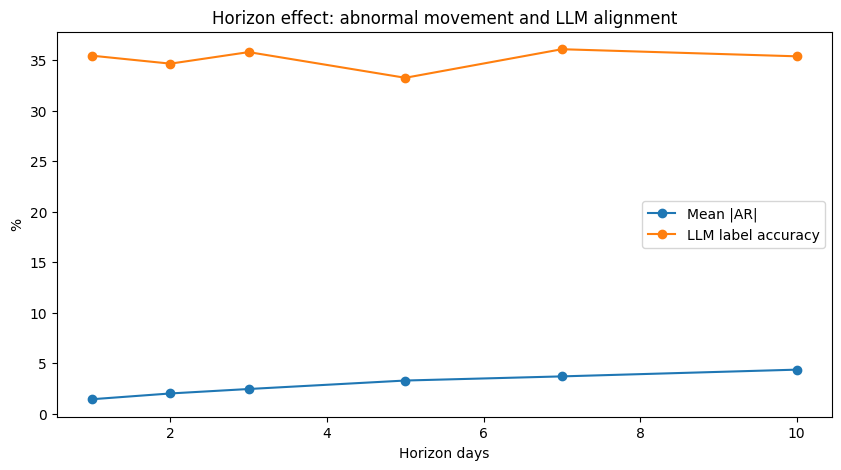

In [24]:
horizon_eval = refined_returns.copy()
horizon_eval["horizon_realised_label"] = horizon_eval["abnormal_return"].map(lambda x: realised_label(float(x), RETURN_THRESHOLD))
horizon_eval["llm_correct"] = horizon_eval["expected_label"].eq(horizon_eval["horizon_realised_label"])

horizon_summary = (
    horizon_eval
    .groupby("horizon_days")
    .agg(
        n=("abnormal_return", "size"),
        mean_ar_pct=("abnormal_return", lambda s: 100*s.mean()),
        mean_abs_ar_pct=("abnormal_return", lambda s: 100*s.abs().mean()),
        llm_expected_label_accuracy_pct=("llm_correct", lambda s: 100*s.mean()),
        bullish_rate_pct=("horizon_realised_label", lambda s: 100*(s == "bullish").mean()),
        bearish_rate_pct=("horizon_realised_label", lambda s: 100*(s == "bearish").mean()),
        neutral_rate_pct=("horizon_realised_label", lambda s: 100*(s == "neutral").mean()),
    )
    .reset_index()
)
display(horizon_summary)

if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(horizon_summary["horizon_days"], horizon_summary["mean_abs_ar_pct"], marker="o", label="Mean |AR|")
    ax.plot(horizon_summary["horizon_days"], horizon_summary["llm_expected_label_accuracy_pct"], marker="o", label="LLM label accuracy")
    ax.set_title("Horizon effect: abnormal movement and LLM alignment")
    ax.set_xlabel("Horizon days")
    ax.set_ylabel("%")
    ax.legend()
    plt.show()


In [25]:
by_label_horizon = (
    horizon_eval
    .groupby(["expected_label", "horizon_days"])
    .agg(
        n=("abnormal_return", "size"),
        mean_ar_pct=("abnormal_return", lambda s: 100*s.mean()),
        mean_abs_ar_pct=("abnormal_return", lambda s: 100*s.abs().mean()),
        realised_bullish_pct=("horizon_realised_label", lambda s: 100*(s == "bullish").mean()),
        realised_bearish_pct=("horizon_realised_label", lambda s: 100*(s == "bearish").mean()),
        realised_neutral_pct=("horizon_realised_label", lambda s: 100*(s == "neutral").mean()),
    )
    .reset_index()
)
display(by_label_horizon)


,expected_label,horizon_days,n,mean_ar_pct,mean_abs_ar_pct,realised_bullish_pct,realised_bearish_pct,realised_neutral_pct
0,bearish,1,88,-0.237429,1.284069,34.090909,40.909091,25.000000
1,bearish,2,88,-0.217467,2.102893,44.318182,44.318182,11.363636
2,bearish,3,88,-0.251336,2.675703,45.454545,42.045455,12.500000
3,bearish,5,88,-0.202277,3.338155,42.045455,44.318182,13.636364
4,bearish,7,87,-0.275667,4.242344,41.379310,48.275862,10.344828
5,bearish,10,87,-0.603573,4.863122,42.528736,54.022989,3.448276
6,bullish,1,182,0.301849,1.664427,37.912088,32.967033,29.120879
7,bullish,2,182,0.226937,2.072645,38.461538,38.461538,23.076923
8,bullish,3,181,0.094667,2.482649,41.436464,45.856354,12.707182
9,bullish,5,181,0.019643,3.479021,41.436464,46.961326,11.602210


## 15. Direct-company contamination checks

One major caveat from the first inspection: some headlines are attached to a requested ticker but appear mainly about another company.

Examples observed in the test set included headlines about Opendoor, Vistra, Vornado, BlackLine, IRDM, etc. If such rows are included, the model may be judged against the wrong stock's return.

This section uses a rough heuristic. It is not perfect, but it helps find rows worth manually auditing.


In [26]:
ALIASES = {
    "AAPL": ["apple", "iphone", "ipad", "mac", "vision pro"],
    "AMZN": ["amazon", "aws", "prime"],
    "GOOGL": ["google", "alphabet", "youtube", "waymo", "gemini"],
    "META": ["meta", "facebook", "instagram", "whatsapp", "threads"],
    "MSFT": ["microsoft", "azure", "xbox", "windows", "openai"],
    "NVDA": ["nvidia", "geforce", "cuda"],
    "TSLA": ["tesla", "musk", "cybertruck", "model y", "model 3"],
}

def headline_mentions_ticker(row) -> bool:
    title = str(row["representative_title"]).lower()
    ticker = row["ticker"]
    return any(alias in title for alias in ALIASES.get(ticker, [ticker.lower()]))

primary["headline_mentions_target"] = primary.apply(headline_mentions_ticker, axis=1)

print("Potential target-mismatch rate by period")
display(
    primary.groupby("period")["headline_mentions_target"]
    .agg(n="size", mentions_target="sum", mention_rate=lambda s: 100*s.mean())
)

print("Examples where headline does not mention target alias")
display(
    primary.loc[~primary["headline_mentions_target"],
                ["period", "ticker", "event_date", "representative_title", "event_type", "event_subtype", "valuation_channel", "expected_label", "realised_label", "abnormal_return"]]
    .head(80)
)


Potential target-mismatch rate by period


,n,mentions_target,mention_rate
period,,,
discovery,177,96,54.237288
test,63,35,55.555556
validation,140,75,53.571429


Examples where headline does not mention target alias


,period,ticker,event_date,representative_title,event_type,event_subtype,valuation_channel,expected_label,realised_label,abnormal_return
2,discovery,AAPL,2023-07-05,"Settlement checks in the mail from Roundup, EpiPen, Zoom, others",regulatory_legal_outcome,lawsuit_settlement,legal_liability,neutral,neutral,-0.001181
20,discovery,AAPL,2023-08-29,"Apellis to lay off 25% of staff, trim research in major restructuring",regulatory_legal_outcome,layoffs_cost_cutting,cost_margin,bearish,bullish,0.022468
26,discovery,AAPL,2023-09-22,Calix taps Jabil as part of $42B+ broadband manufacturing plan,strategy_capital_allocation,partnership_customer_deal,unclear,neutral,neutral,0.004774
56,discovery,AAPL,2024-01-10,Software Glitch Behind Recalled App Could Drastically Increase Insulin Delivery,regulatory_legal_outcome,product_failure,revenue_demand,bearish,neutral,0.000068
62,discovery,AAPL,2024-01-30,"Corning beats quarterly sales estimates, signals improving demand for fiber optics",demand_supply_revision,delivery_beat,revenue_demand,bullish,bearish,-0.019927
92,discovery,AAPL,2024-05-20,"Jabil replaces CEO after investigation, pulls 2025 forecast",regulatory_legal_outcome,regulatory_threat,management_strategy,bearish,bullish,0.008228
98,discovery,AAPL,2024-06-11,"MAX ARRIVES IN FRANCE AND POLAND, AND ENHANCED OFFERING ROLLS OUT IN NETHERLANDS AND BELGIUM COMPLETING INITIAL PHASE OF EUROPEAN LAUNCHES | Pressroom",strategy_capital_allocation,other,revenue_demand,bullish,bullish,0.099555
134,discovery,AAPL,2024-11-21,"Applied Materials launches a maskless OLED production technology, to support 8-Gen high efficiency OLED deposition and encapsulation",novel_product_event,product_launch,product_adoption,bullish,neutral,0.003480
164,validation,AAPL,2025-03-11,SanDisk to Hike NAND Prices by Over 10% as US Memory Giant Expects Supply to Tighten,demand_supply_revision,supply_constraint,revenue_demand,bullish,bearish,-0.065046
176,validation,AAPL,2025-04-29,"Sony mulls spin-off of chip business, says report",strategy_capital_allocation,other,unclear,neutral,neutral,-0.002370


## 16. What to conclude from this run

Current careful conclusion:

> The LLM-only expected labels are weak as a direct bullish/bearish/neutral classifier. The LTN/rule layer improves performance when it fires, but it is selective and not yet a complete market-state classifier.

What looks promising:

- `earnings_guidance` with high materiality often gives cleaner bullish signals.
- `demand_supply_revision` repeatedly behaves like a bearish-pressure category.
- LTN/rule-matched events outperform LLM-only expected labels on the held-out period.

What is currently limiting the result:

- Some requested-ticker rows appear to be about other companies.
- Neutral is underrepresented at a `0.5%` threshold.
- The held-out test set is small: 63 primary-horizon events, 20 rule-matched events.
- The current LLM still sees event text mostly in isolation; rolling market/news context is not yet included as LTN features.

The next best prototype is not another expensive full-news run. It is a cleaner evaluation pass:

1. add direct-company filters,
2. test neutral thresholds,
3. add rolling pre-event context features,
4. rerun LTN/rule evaluation from the existing refined outputs.
